<a href="https://colab.research.google.com/github/jcvl-udg/collab_notebooks/blob/main/WSC_1_Tutorial00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Working with Celestial Coordinates in WCS 1: Specifying, reading, and plotting](https://learn.astropy.org/tutorials/celestial_coords1.html)

In [ ]:
#!pip install astropy
#!pip install matplotlib

Importamos herramientas necesarias

In [ ]:
from astropy.wcs import WCS
from astropy.io import fits
import matplotlib.pyplot as plt

### Section 1: Two ways to create an astropy.wcs.WCS object

### Method 1: Building a WCS object with a dictionary-¿
- Se puede generar la data con el formato FITS especifico que se ofrece en [esta pagina](https://fits.gsfc.nasa.gov/fits_wcs.html).



In [ ]:
# NGC 7293
wcs_input_dict = {
    'CTYPE1': 'RA---TAN',
    'CUNIT1': 'deg',
    'CDELT1': -0.0002777777778,
    'CRPIX1': 1,
    'CRVAL1': 337.5202808,
    'NAXIS1': 1024,
    'CTYPE2': 'DEC--TAN',
    'CUNIT2': 'deg',
    'CDELT2': 0.0002777777778,
    'CRPIX2': 1,
    'CRVAL2': -20.833333059999998,
    'NAXIS2': 1024
}
wcs_helix_dict = WCS(wcs_input_dict)

In [ ]:
wcs_helix_dict # To check output

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 337.5202808 -20.833333059999998 
CRPIX : 1.0 1.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0002777777778 0.0002777777778 
NAXIS : 1024  1024

- CRVALn: the coordinate value at a reference point (e.g., RA and DEC value in degrees)
- CRPIXn: the pixel location of the reference point (e.g., CRPIX1=1, CRPIX2=1 describes the center of a corner pixel)
- CDELTn: the coordinate increment at the reference point (e.g., the difference in 'RA' value from the reference pixel to its neighbor along the RA axis)
- CTYPEn: an 8-character string describing the axis type (e.g., 'RA---TAN' and 'DEC---TAN' describe the typical tangent-plane sky projection that astronomers use)
- CUNITn: a string describing the unit for each axis (if not specified, the default unit is degrees.)
- NAXISn: an integer defining the number of pixels in each axis

### Method 2: Create an empty WCS object before assigning values

In [ ]:
wcs_helix_list = WCS(naxis=2)
wcs_helix_list.wcs.crpix = [1, 1]
wcs_helix_list.wcs.crval = [337.5202808, -20.833333059999998]
wcs_helix_list.wcs.cunit = ["deg", "deg"]
wcs_helix_list.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs_helix_list.wcs.cdelt = [-0.0002777777778, 0.0002777777778]

In [ ]:
wcs_helix_list # To check output

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 337.5202808 -20.833333059999998 
CRPIX : 1.0 1.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0002777777778 0.0002777777778 
NAXIS : 0  0

Note that when we initialize the WCS object this way, the NAXIS values are set to 0. To assign coordinates to our image, we will need to fix the shape of the WCS object array so that it matches our image. We can do this by assigning a value to the array_shape attribute of the WCS object:

In [ ]:
wcs_helix_list.array_shape = [1024, 1024]

In [ ]:
wcs_helix_list

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 337.5202808 -20.833333059999998 
CRPIX : 1.0 1.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0002777777778 0.0002777777778 
NAXIS : 1024  1024

# Section 2: Show an image of the Helix nebula with RA and Dec labeled

### Step 1: Read in the FITS file

In [ ]:
header_data_unit_list = fits.open('https://github.com/astropy/astropy-data/raw/6d92878d18e970ce6497b70a9253f65c925978bf/tutorials/celestial-coords1/tailored_dss.22.29.38.50-20.50.13_60arcmin.fits')

In [ ]:
header_data_unit_list.info()

Filename: /root/.astropy/cache/download/url/21d072715b8ee90ab2fe1405b0e5fb1a/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     121   (2119, 2119)   int16   


In [ ]:
image = header_data_unit_list[0].data
header = header_data_unit_list[0].header

In [ ]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2119                                                  
NAXIS2  =                 2119                                                  
DATE    = '03/09/19          ' /Date of FITS file creation                      
ORIGIN  = 'CASB -- STScI     ' /Origin of FITS image                            
PLTLABEL= 'J 10265           ' /Observatory plate label                         
PLATEID = '04I5              ' /GSSS Plate ID                                   
REGION  = 'S602              ' /GSSS Region Name                                
DATE-OBS= '1985-06-15'         / UT date of Observation                         
UT      = '18:30:00.00       ' /UT time of observation                          
EPOCH   =  1.9854542236328E+

### Step 2: Read in the FITS image coordinate system with astropy.wcs.WCS

In [ ]:
wcs_helix = WCS(header)

In [ ]:
wcs_helix

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 336.6811440416667 -19.745016572222223 
CRPIX : 2499.6447489941065 3378.9002584168584 
PC1_1 PC1_2  : 0.025282857855146917 4.4684674035885186e-05 
PC2_1 PC2_2  : -4.8420685266167345e-05 0.0252859566668733 
CDELT : -0.01867333422948538 0.01867333422948538 
NAXIS : 2119  2119

### Step 3: Plot the Helix nebula with sky coordinate axes (RA and Dec)

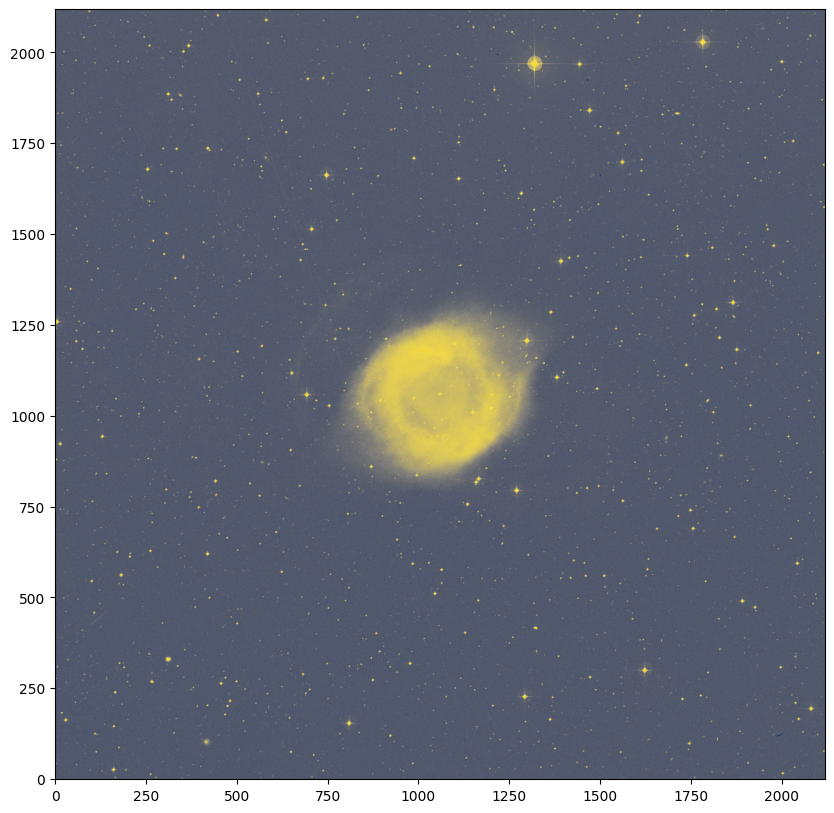

In [ ]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(image, origin='lower', cmap='cividis')

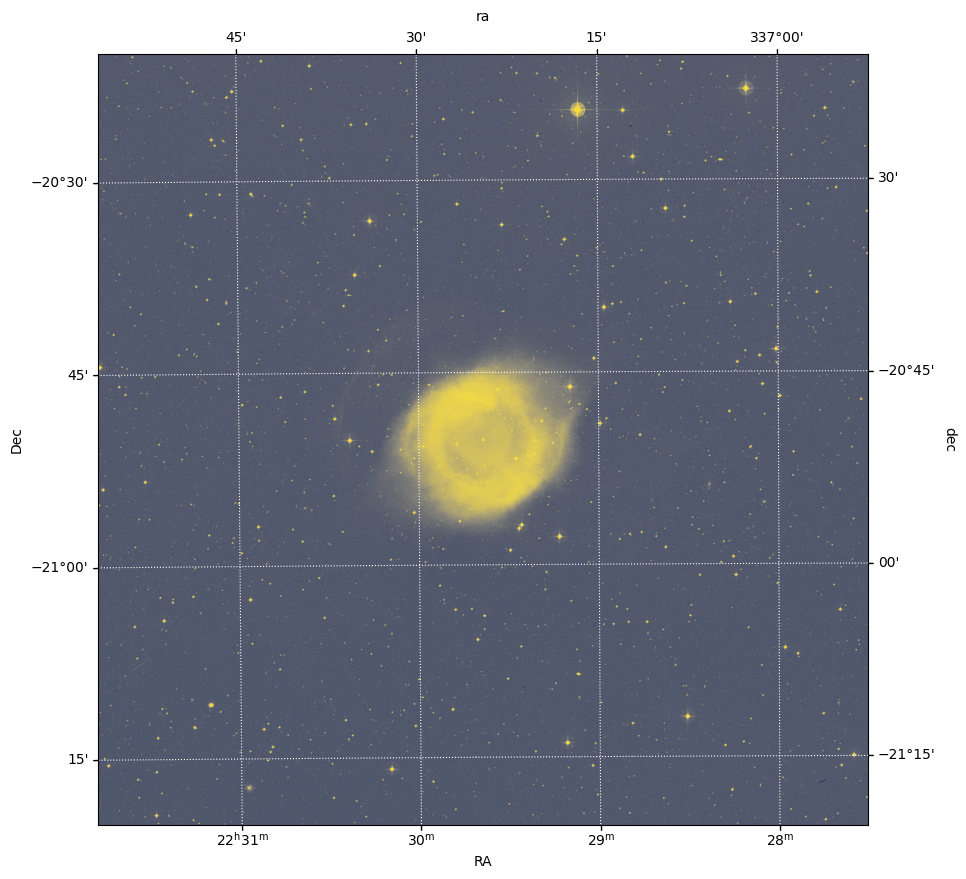

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(projection=wcs_helix)
plt.imshow(image, origin='lower', cmap='cividis', aspect='equal')
plt.xlabel(r'RA')
plt.ylabel(r'Dec')

overlay = ax.get_coords_overlay('icrs')
overlay.grid(color='white', ls='dotted')

## Exercise

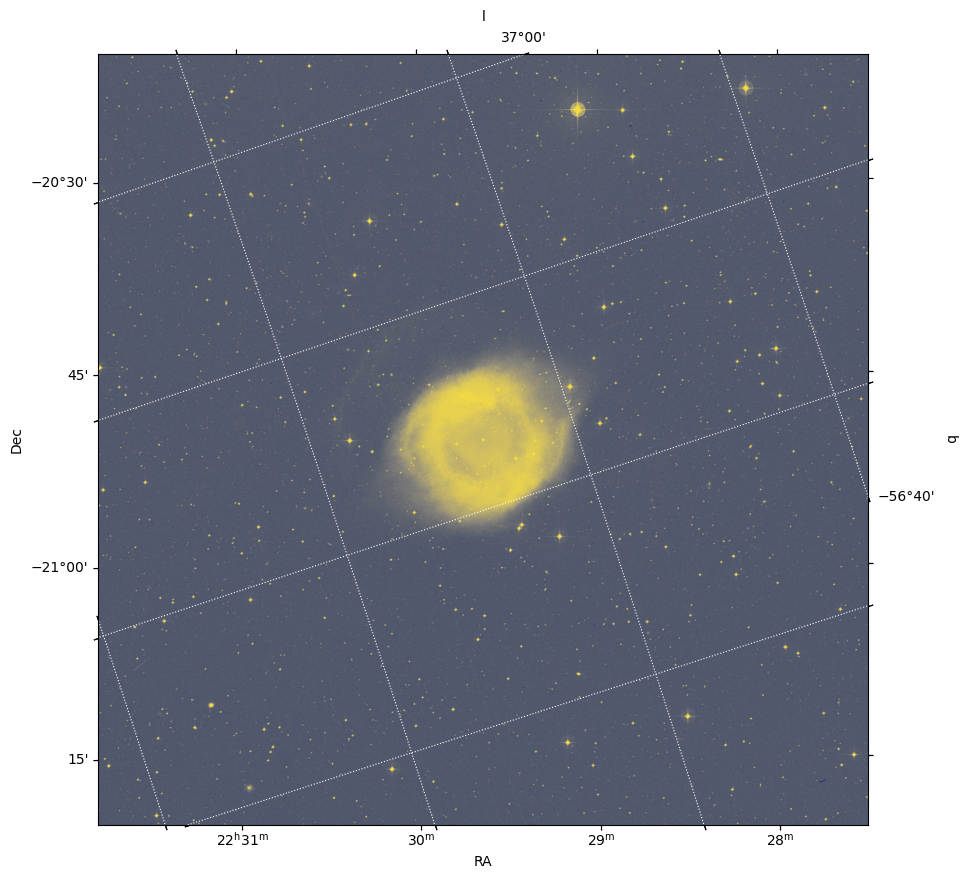

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(projection=wcs_helix)
plt.imshow(image, origin='lower', cmap='cividis', aspect='equal')
plt.xlabel(r'RA')
plt.ylabel(r'Dec')

overlay = ax.get_coords_overlay('galactic')
overlay.grid(color='white', ls='dotted')

### Section 3: Plot a scale marker on an image with WCS

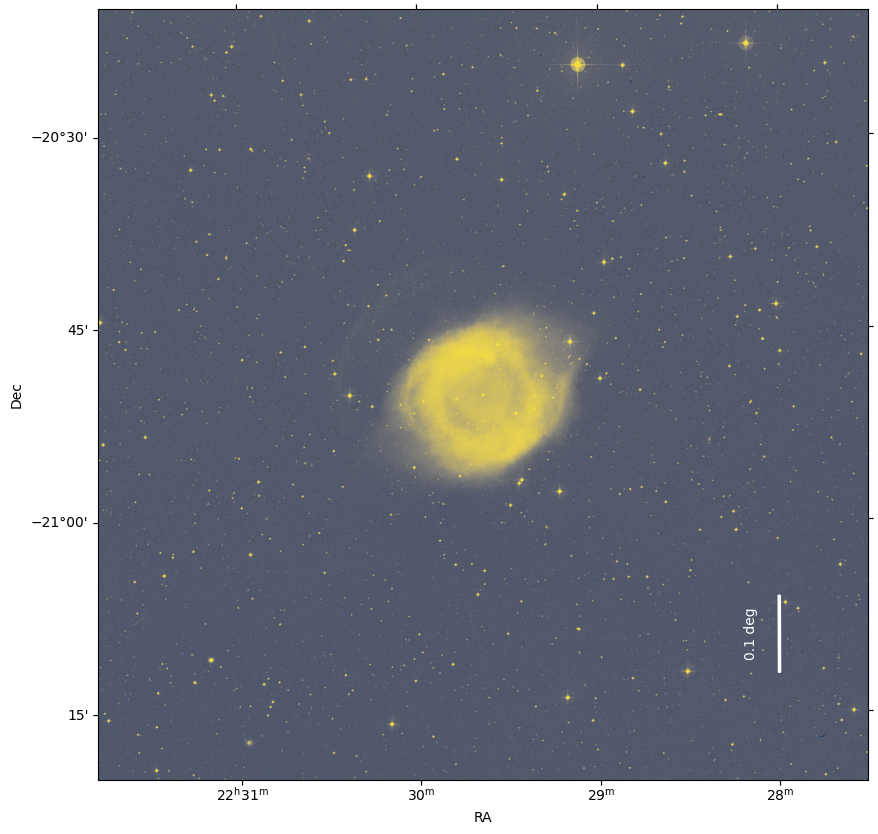

In [ ]:
fig = plt.figure(figsize=(10, 10), frameon=False)
ax = plt.subplot(projection=wcs_helix)
ax.arrow(337, -21.2, 0, 0.1,
         head_width=0, head_length=0,
         fc='white', ec='white', width=0.003,
         transform=ax.get_transform('icrs'))
plt.text(337.05, -21.18, '0.1 deg',
         color='white', rotation=90,
         transform=ax.get_transform('icrs'))
plt.imshow(image, origin='lower', cmap='cividis', aspect='equal')
plt.xlabel(r'RA')
plt.ylabel(r'Dec')

### Exercise
Make a horizontal bar with the same length. Keep in mind that 1 hour angle = 15 degrees.

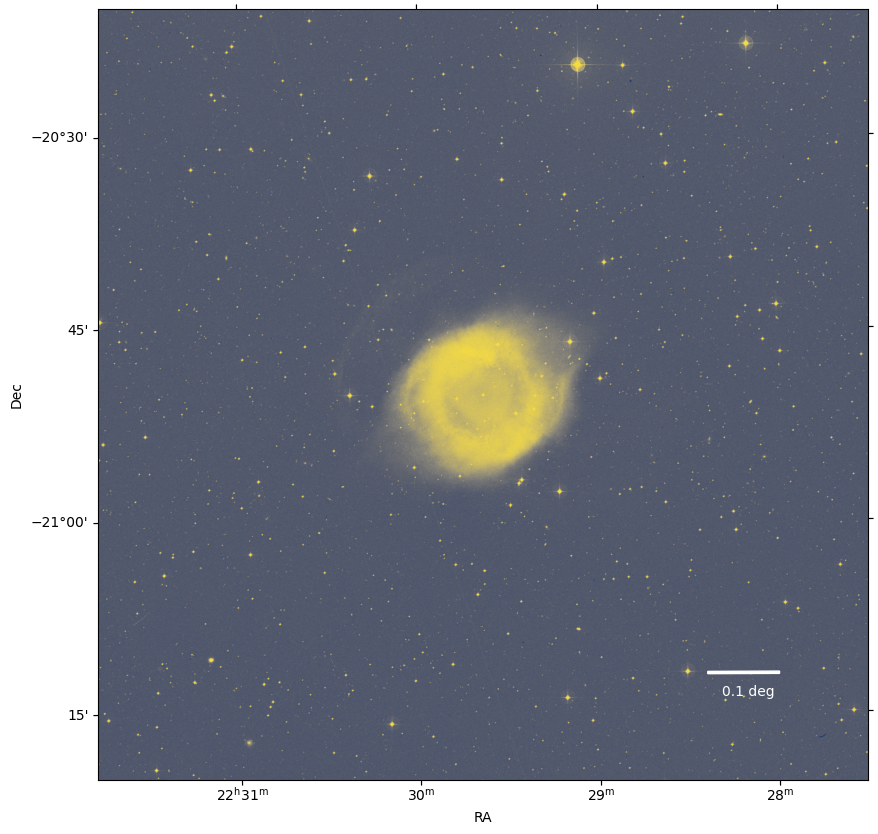

In [ ]:
fig = plt.figure(figsize=(10, 10), frameon=False)
ax = plt.subplot(projection=wcs_helix)
# Horizontal reference bar (0.1 degrees in RA)
ax.arrow(337, -21.2, 0.1, 0,
         head_width=0, head_length=0,
         fc='white', ec='white', width=0.003,
         transform=ax.get_transform('icrs'))
plt.text(337.08, -21.23, '0.1 deg',
         color='white', rotation=0,
         transform=ax.get_transform('icrs'))
plt.imshow(image, origin='lower', cmap='cividis', aspect='equal')
plt.xlabel(r'RA')
plt.ylabel(r'Dec')

### Trying M 77

In [1]:
!pip install astroquery
!pip install astropy
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.6/997.6 kB 25.9 MB/s eta 0:00:00


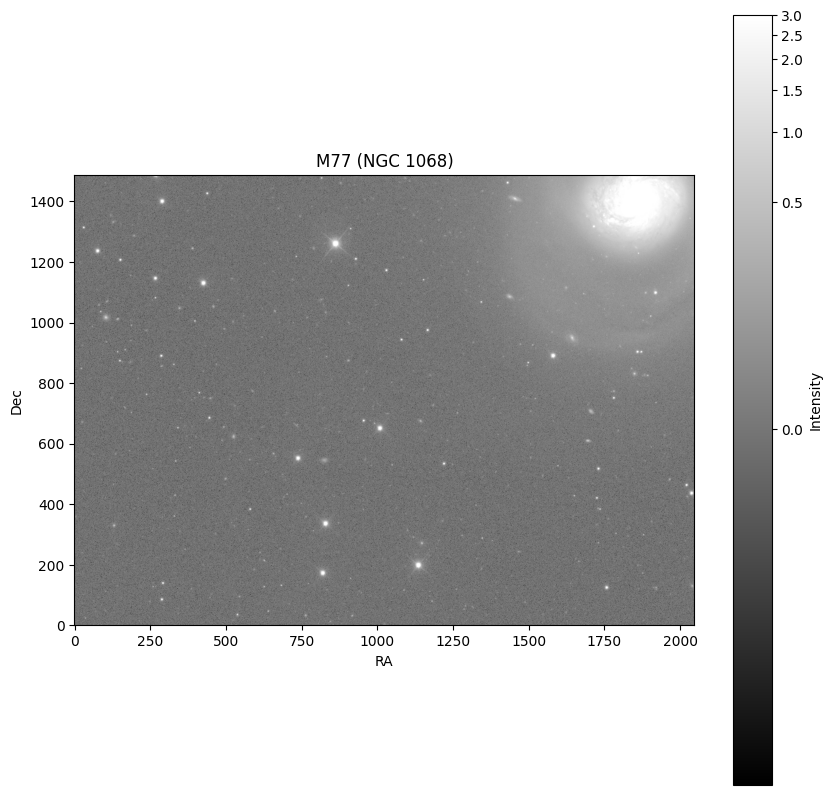

In [10]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from astropy import units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

# Define the coordinates of M77 (NGC 1068) in decimal degrees
m77_coords = coords.SkyCoord(ra=40.66967, dec=-0.01322, unit='deg', frame='icrs')

# Query SDSS for FITS files with a radius of 3 arcminutes
result = SDSS.get_images(coordinates=m77_coords, radius=3.0 * u.arcmin, band='r')

# Save the FITS file
result[0].writeto('m77_sdss_r_band.fits', overwrite=True)

# Load the FITS file
file_path = 'm77_sdss_r_band.fits'
data = fits.getdata(file_path)

# Normalize the data for better visualization
norm = simple_norm(data, stretch='log', percent=99)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='Intensity')
plt.title('M77 (NGC 1068)')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.show()

/usr/local/lib/python3.11/dist-packages/astropy/visualization/lupton_rgb.py:614: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


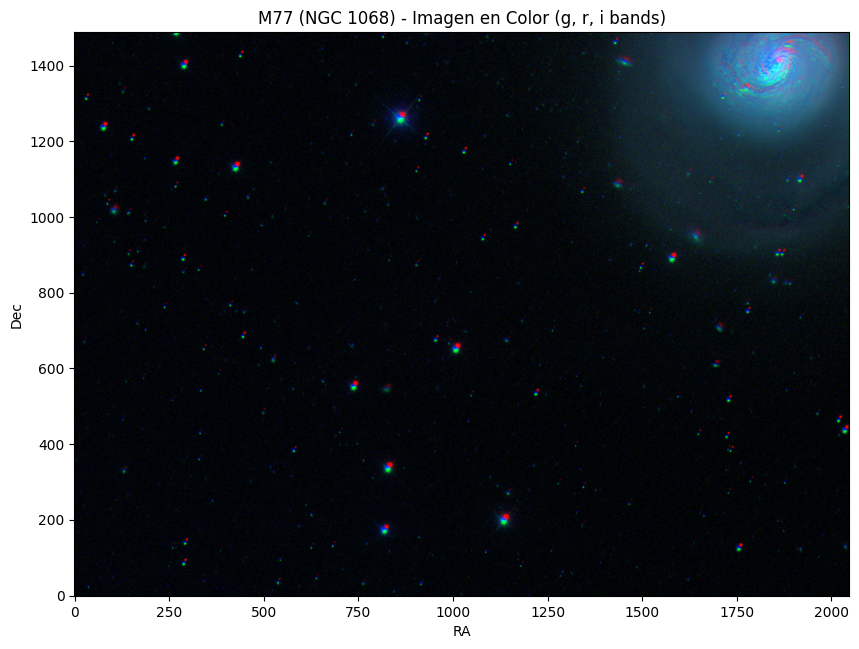

In [24]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb

# Define las coordenadas de M77 (NGC 1068) en decimal grados
m77_coords = coords.SkyCoord(ra=40.66967, dec=-0.01322, unit='deg', frame='icrs')

# Bandas de interés
bands = ['g', 'r', 'i']
images = []

for band in bands:
    result = SDSS.get_images(coordinates=m77_coords, radius=3.0 * u.arcmin, band=band)

    if result:  # Verificar si la consulta devolvió datos
        hdu_list = result[0]  # Primer HDUList
        primary_hdu = hdu_list[0]  # Obtener el PrimaryHDU

        if hasattr(primary_hdu, 'data') and primary_hdu.data is not None:
            data = primary_hdu.data.astype(float)  # Convertir a flotante
            images.append(data)
        else:
            print(f"No se encontraron datos en el PrimaryHDU para la banda {band}")
    else:
        print(f"No se obtuvo imagen para la banda {band}")

# Verificar si se obtuvieron las tres imágenes
if len(images) == 3:
    # Apilar las imágenes en un array RGB
    rgb_image = np.stack(images, axis=-1)

    # Crear imagen en color con el algoritmo de Lupton
    color_image = make_lupton_rgb(rgb_image[..., 0],  # g-band -> Verde
                                  rgb_image[..., 1],  # r-band -> Rojo
                                  rgb_image[..., 2],  # i-band -> Azul
                                  stretch=0.5, Q=10)

    # Mostrar la imagen
    plt.figure(figsize=(10, 10))
    plt.imshow(color_image, origin='lower')
    plt.title('M77 (NGC 1068) - Imagen en Color (g, r, i bands)')
    plt.xlabel('RA')
    plt.ylabel('Dec')
    plt.show()
else:
    print("No se pudieron obtener las tres imágenes necesarias para la composición RGB.")

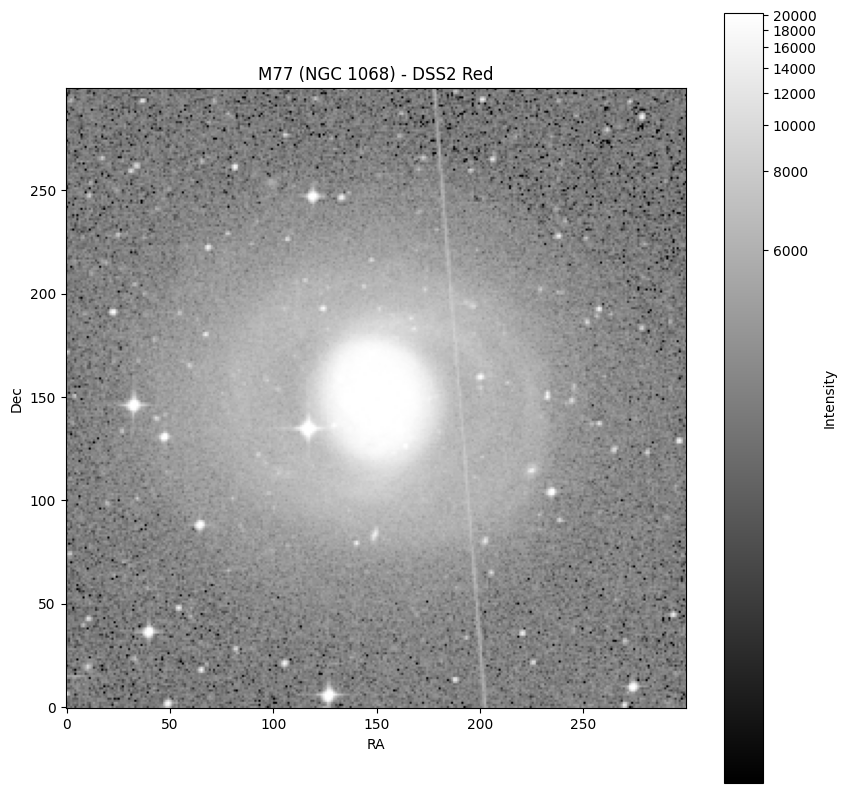

In [11]:
from astroquery.skyview import SkyView
from astropy import coordinates as coords
from astropy import units as u

# Define the coordinates of M77
m77_coords = coords.SkyCoord(ra=40.66967, dec=-0.01322, unit='deg', frame='icrs')

# Query SkyView for DSS2 Red data
result = SkyView.get_images(position=m77_coords, survey='DSS2 Red', radius=0.1 * u.deg)

# Save the FITS file
result[0].writeto('m77_dss_red.fits')

# Load and plot the FITS file
file_path = 'm77_dss_red.fits'
data = fits.getdata(file_path)

# Normalize the data for better visualization
norm = simple_norm(data, stretch='log', percent=99)

# Plot the image
plt.figure(figsize=(10, 10))
plt.imshow(data, cmap='gray', origin='lower', norm=norm)
plt.colorbar(label='Intensity')
plt.title('M77 (NGC 1068) - DSS2 Red')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.show()

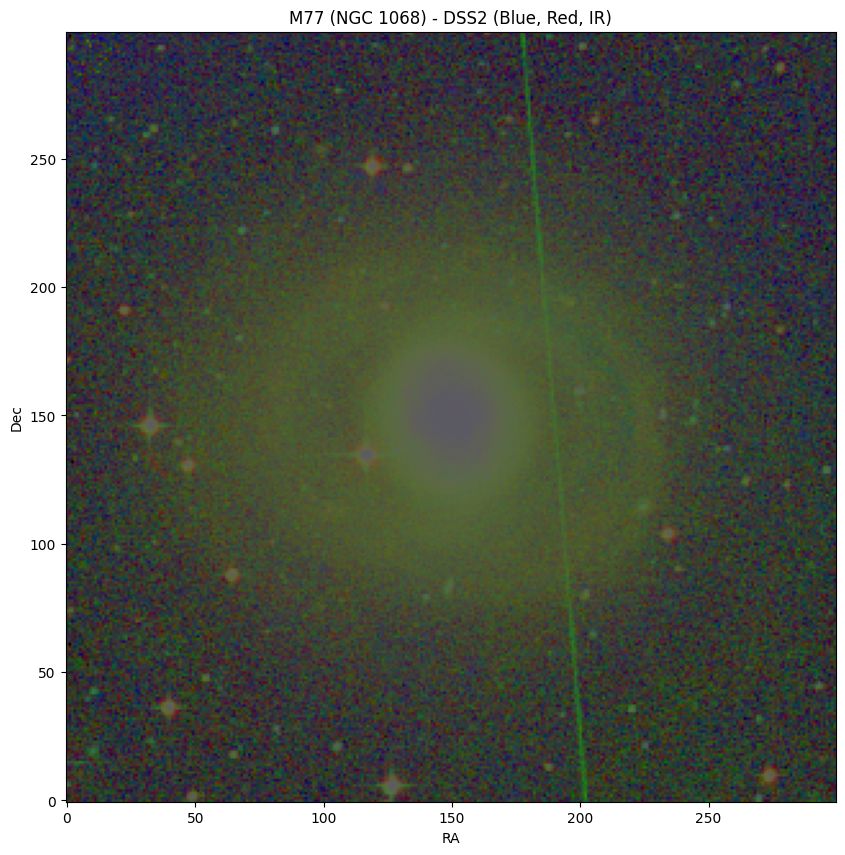

In [27]:
from astroquery.skyview import SkyView
from astropy import coordinates as coords
from astropy import units as u
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb, simple_norm

# Definir coordenadas de M77
m77_coords = coords.SkyCoord(ra=40.66967, dec=-0.01322, unit='deg', frame='icrs')

# Definir las bandas a consultar
bands = ['DSS2 Blue', 'DSS2 Red', 'DSS2 IR']
images = []

# Consultar imágenes en las tres bandas
for band in bands:
    result = SkyView.get_images(position=m77_coords, survey=band, radius=0.1 * u.deg)

    if result:
        hdu_list = result[0]  # Tomar la imagen FITS
        data = hdu_list[0].data  # Extraer datos de la imagen

        if data is not None:
            # Normalizar cada banda individualmente para evitar sobreexposición
            norm = simple_norm(data, stretch='asinh', percent=99)
            images.append(norm(data))
        else:
            print(f"No se pudo extraer datos para {band}.")
    else:
        print(f"No se obtuvo imagen para {band}.")

# Verificar que se obtuvieron las tres bandas
if len(images) == 3:
    # Convertir a un array de numpy y apilar en formato RGB
    rgb_image = np.stack(images, axis=-1)

    # Normalización con la técnica de Lupton
    color_image = make_lupton_rgb(rgb_image[..., 0],  # Azul
                                  rgb_image[..., 1],  # Rojo
                                  rgb_image[..., 2],  # Infrarrojo
                                  stretch=0.2,  # 🔹 Reducido para evitar saturación
                                  Q=20)  # 🔹 Aumentado para resaltar detalles sin sobreexponer

    # Mostrar la imagen en color
    plt.figure(figsize=(10, 10))
    plt.imshow(color_image, origin='lower')
    plt.title('M77 (NGC 1068) - DSS2 (Blue, Red, IR)')
    plt.xlabel('RA')
    plt.ylabel('Dec')
    plt.show()
else:
    print("No se obtuvieron las tres bandas necesarias para la imagen RGB.")